In [1]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from imblearn.over_sampling import KMeansSMOTE
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors


In [3]:
def kmeans_smote_for_regression(X_tr, y_tr, cluster_tr, *,
                               sampling_strategy="not majority",
                               random_state=0,
                               k_neighbors=3,
                               mp_knn=5):
    """
    Oversample X within training set using KMeansSMOTE on cluster labels,
    then assign MP to synthetic points using kNN average of real samples
    from the same cluster.

    Returns: X_aug, y_aug, cluster_aug
    """
    X_tr = np.asarray(X_tr, dtype=np.float32)
    y_tr = np.asarray(y_tr, dtype=np.float32)
    cluster_tr = np.asarray(cluster_tr)

    # ---- Build a safe sampling_strategy dict (skip tiny clusters) ----
    vc = pd.Series(cluster_tr).value_counts()

    # SMOTE needs at least k_neighbors + 1 points in a class to even work
    min_required = max(k_neighbors + 1, 6)   # 6 is a practical floor
    eligible = vc[vc >= min_required].index.tolist()

    # If caller passed a string strategy, convert it into a dict strategy
    if isinstance(sampling_strategy, str):
        # Raise eligible clusters up to the median size (conservative)
        target = int(vc[eligible].median()) if len(eligible) else int(vc.median())
        sampling_strategy = {
            int(cl): target
            for cl in eligible
            if vc[cl] < target
        }

    # If nothing is eligible to oversample, return unchanged
    if not sampling_strategy:
        return X_tr, y_tr, cluster_tr

    # ---- KMeansSMOTE with small internal kmeans ----
    kms = KMeansSMOTE(
        sampling_strategy=sampling_strategy,
        random_state=random_state,
        k_neighbors=min(k_neighbors, min_required - 1),
        cluster_balance_threshold=0.01,                 # more permissive
        kmeans_estimator=KMeans(n_clusters=2, random_state=random_state)  # key fix
    )

    X_res, cluster_res = kms.fit_resample(X_tr, cluster_tr)

    n_orig = X_tr.shape[0]
    n_new  = X_res.shape[0] - n_orig

    # If nothing got generated, just return original
    if n_new <= 0:
        return X_tr, y_tr, cluster_tr

    X_syn = X_res[n_orig:]
    cluster_syn = cluster_res[n_orig:]

    # --- Assign MP to synthetic points ---
    y_syn = np.empty((n_new,), dtype=np.float32)

    # Build per-cluster neighbor structures on REAL points only
    for cl in np.unique(cluster_syn):
        real_idx = np.where(cluster_tr == cl)[0]
        syn_idx  = np.where(cluster_syn == cl)[0]

        # If a cluster has too few real points, fallback to global neighbors
        if len(real_idx) < 2:
            nn = NearestNeighbors(n_neighbors=min(mp_knn, len(X_tr))).fit(X_tr)
            dists, inds = nn.kneighbors(X_syn[syn_idx])
            y_syn[syn_idx] = y_tr[inds].mean(axis=1).astype(np.float32)
            continue

        nn = NearestNeighbors(n_neighbors=min(mp_knn, len(real_idx))).fit(X_tr[real_idx])
        dists, inds = nn.kneighbors(X_syn[syn_idx])
        y_syn[syn_idx] = y_tr[real_idx][inds].mean(axis=1).astype(np.float32)

    # Combine
    X_aug = np.vstack([X_tr, X_syn]).astype(np.float32)
    y_aug = np.concatenate([y_tr, y_syn]).astype(np.float32)
    cluster_aug = np.concatenate([cluster_tr, cluster_syn])

    return X_aug, y_aug, cluster_aug

In [4]:
df = pd.read_parquet("../Ro5/artifacts/full_data_50_50_no_interaction_scaled.parquet")
df.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
0,CC(Oc1cc(N)c(cc1Cl)Cl)C,42.0,1,-0.246914,-0.318041,-0.252489,-0.037090,-0.264118,-0.305822,0.282657,...,-0.189949,-0.607761,-0.428275,-0.503703,-0.611085,-0.465382,2.929191,-0.081507,-0.151437,Train
1,Nc1ccc(cc1)S(=O)(=O)Nc1nnc(s1)C(C)(C)C,222.0,1,-0.246914,-0.027871,-0.252489,0.478583,0.213938,-0.319661,0.061296,...,-0.189949,-0.308585,0.926000,-0.503703,-0.611085,1.302247,2.929191,-0.081507,1.311127,Train
2,O=S1(=O)CCCCO1,13.5,1,-0.246914,-0.941911,-0.252489,0.686505,-0.304418,0.013022,0.636835,...,-0.189949,-0.765565,-0.428275,0.457273,-0.611085,-0.236538,-0.275426,-0.081507,-0.151437,Train
3,Cc1cc(C)c2c(c1)CC2=O,48.0,1,-0.246914,-0.968674,-0.252489,-0.663230,0.264803,-0.186582,0.636835,...,-0.189949,-0.092729,-0.428275,0.457273,1.636434,-0.977747,-0.275426,-0.081507,-1.248361,Train
4,C#CC1(CCCCC1)OC(=N)O,96.0,1,3.204934,-0.497337,-0.252489,-0.663230,0.467373,1.562280,0.636835,...,-0.189949,-0.191508,-0.428275,0.457273,-0.611085,0.043600,-0.275426,-0.081507,-0.517079,Train


In [5]:
df_bro5 = df[
    (df["Type"] == "Train") &
    (df["Ro5"] == 0)
].copy()

print("Shape:", df_bro5.shape)
print(df_bro5[["Type", "Ro5"]].value_counts())

Shape: (183, 105)
Type   Ro5
Train  0      183
Name: count, dtype: int64


In [6]:
df_bro5.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
49,OCC1OC(Oc2c(oc3c(c2=O)c(O)cc(c3)OC)c2ccc(c(c2)...,187.0,0,-0.246914,2.207878,-0.252489,0.834689,-0.541532,-3.704046,-0.409599,...,-0.189949,1.873493,4.181811,1.418249,1.636434,5.824469,-0.275426,-0.081507,4.236256,Train
74,CC(CCCC(C1CCC2C1(C)CCC1C2CC(C2(C1(C)CCC(C2)OC(...,164.0,0,-0.246914,1.559489,-0.252489,-0.663230,3.952854,1.872290,-0.258447,...,-0.189949,4.803544,-0.428275,3.340202,1.636434,0.593730,-0.275426,-0.081507,0.214204,Train
86,Oc1ccc(cc1)c1oc2cc(O[C@@H]3O[C@@H](C)[C@@H]([C...,194.5,0,-0.246914,3.012081,-0.252489,0.058269,-0.264118,-5.121954,-1.266870,...,-0.189949,2.507936,5.841819,2.379225,1.636434,7.224875,-0.275426,-0.081507,5.333179,Train
207,N=C(NC(=N)Nc1ccc(cc1)Cl)NCCCCCCNC(=N)NC(=N)Nc1...,134.0,0,13.560479,2.896249,-0.252489,1.927431,0.210109,0.437800,-1.936161,...,-0.189949,0.529009,-0.428275,-0.503703,-0.611085,3.264056,-0.275426,-0.081507,2.773692,Train
277,C=CCOc1c(Br)cc(cc1Br)C(c1cc(Br)c(c(c1)Br)OCC=C...,119.0,0,-0.246914,1.419805,-0.252489,0.779768,0.181705,0.385561,-1.580054,...,-0.189949,0.398444,-0.428275,-0.503703,-0.611085,-0.938573,-0.275426,-0.081507,0.579845,Train


X_scaled shape: (183, 101)
Num features: 101


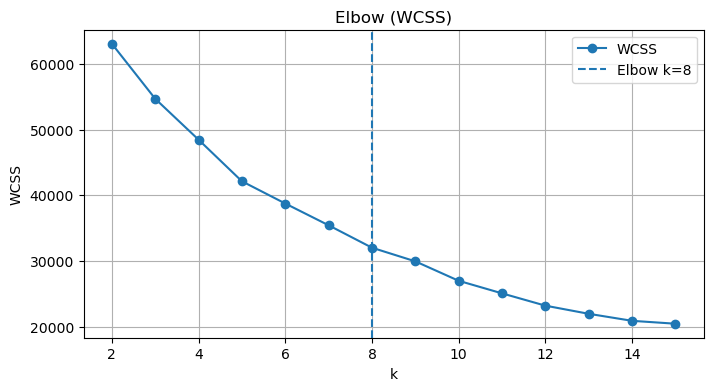

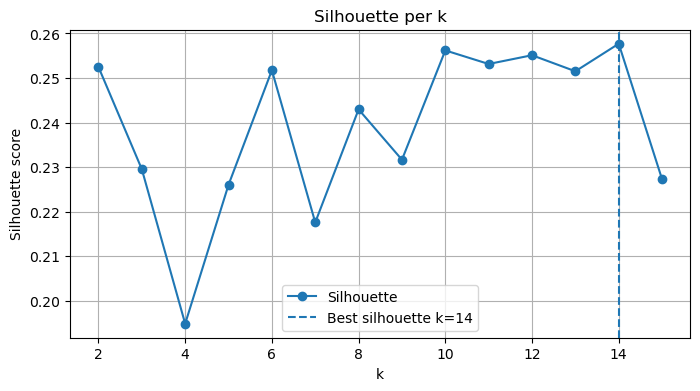

Elbow k: 8 | Best silhouette k: 14 | Selected k_opt: 8


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "Ro5"}
num_cols = df_bro5.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_bro5[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_bro5), "Cluster labels length != df rows (mismatch)."

df_clustered = df_bro5.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [8]:
df_clustered.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type,Structure_Cluster
49,OCC1OC(Oc2c(oc3c(c2=O)c(O)cc(c3)OC)c2ccc(c(c2)...,187.0,0,-0.246914,2.207878,-0.252489,0.834689,-0.541532,-3.704046,-0.409599,...,1.873493,4.181811,1.418249,1.636434,5.824469,-0.275426,-0.081507,4.236256,Train,5
74,CC(CCCC(C1CCC2C1(C)CCC1C2CC(C2(C1(C)CCC(C2)OC(...,164.0,0,-0.246914,1.559489,-0.252489,-0.663230,3.952854,1.872290,-0.258447,...,4.803544,-0.428275,3.340202,1.636434,0.593730,-0.275426,-0.081507,0.214204,Train,1
86,Oc1ccc(cc1)c1oc2cc(O[C@@H]3O[C@@H](C)[C@@H]([C...,194.5,0,-0.246914,3.012081,-0.252489,0.058269,-0.264118,-5.121954,-1.266870,...,2.507936,5.841819,2.379225,1.636434,7.224875,-0.275426,-0.081507,5.333179,Train,5
207,N=C(NC(=N)Nc1ccc(cc1)Cl)NCCCCCCNC(=N)NC(=N)Nc1...,134.0,0,13.560479,2.896249,-0.252489,1.927431,0.210109,0.437800,-1.936161,...,0.529009,-0.428275,-0.503703,-0.611085,3.264056,-0.275426,-0.081507,2.773692,Train,3
277,C=CCOc1c(Br)cc(cc1Br)C(c1cc(Br)c(c(c1)Br)OCC=C...,119.0,0,-0.246914,1.419805,-0.252489,0.779768,0.181705,0.385561,-1.580054,...,0.398444,-0.428275,-0.503703,-0.611085,-0.938573,-0.275426,-0.081507,0.579845,Train,3


In [9]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 183
Num features: 101
Num folds: 10

Fold  0 | Train:  164 | Val:   19
Fold  1 | Train:  164 | Val:   19
Fold  2 | Train:  164 | Val:   19
Fold  3 | Train:  165 | Val:   18
Fold  4 | Train:  165 | Val:   18
Fold  5 | Train:  165 | Val:   18
Fold  6 | Train:  165 | Val:   18
Fold  7 | Train:  165 | Val:   18
Fold  8 | Train:  165 | Val:   18
Fold  9 | Train:  165 | Val:   18


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


In [10]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/Ro5_best_models_no_interaction_50/Ro5_best_fold_1.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [192,96,48]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            # clusters for KMeansSMOTE "classes"
            cluster_tr = y_strat[tr_idx]  # y_strat = Structure_Cluster as str
            # (optionally keep as int; str works too but int is nicer)
            cluster_tr = cluster_tr.astype(int)

            X_tr, y_tr, _ = kmeans_smote_for_regression(
                X_tr, y_tr, cluster_tr,
                sampling_strategy="not majority",  # or "auto" / dict per cluster
                random_state=0,
                k_neighbors=3,
                mp_knn=5
            )

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-02-20 00:12:55,571] A new study created in memory with name: no-name-39a64244-3424-4337-b107-c14afb070f98



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=1.39545e-05
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 0] Epoch    1 | Train 72.2142 | Val 52.7148 | ES 0/30
[Fold 0] Early stopping at epoch 31 (best Val Loss: 52.7148)
Fold 1: TL on cpu | freeze=0 | lr=1.39545e-05
Freeze Level 0: all layers trainable
[Fold 1] Epoch    1 | Train 71.1389 | Val 49.3370 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

...

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 5] Early stopping at epoch 31 (best Val Loss: 36.4108)
Fold 6: TL on cpu | freeze=2 | lr=0.000140599
Freeze Level 2: freezing 2 block(s)
[Fold 6] Epoch    1 | Train 84.6909 | Val 62.4571 | ES 0/30
[Fold 6] Early stopping at epoch 31 (best Val Loss: 62.4571)
Fold 7: TL on cpu | freeze=2 | lr=0.000140599
Freeze Level 2: freezing 2 block(s)
[Fold 7] Epoch    1 | Train 72.8350 | Val 59.1099 | ES 0/30
[Fold 7] Early stopping at epoch 31 (best Val Loss: 59.1099)
Fold 8: TL on cpu | freeze=2 | lr=0.000140599
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 79.2638 | Val 38.3082 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

[Fold 8] Early stopping at epoch 31 (best Val Loss: 38.3082)
Fold 9: TL on cpu | freeze=2 | lr=0.000140599
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 84.1128 | Val 66.3100 | ES 0/30
[Fold 9] Early stopping at epoch 31 (best Val Loss: 66.3100)
[freeze_fc1_fc2] Best fold: 5 → artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_5_best.pth

Summary: {
  "no_freeze": {
    "best": 48.33857955932617,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 7,
      "checkpoint": "artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/no_freeze/final_fold_models/fold_7_best.pth",
      "hidden_layers": [
        192,
        96,
        48
      ],
      "best_params": {
        "learning_rate": 0.0009621285417654083,
        "weight_decay": 4.3157494173971655e-05,
        "batch_size": 32,
        "dropout_rate": 0.37904392540513676
      }
   

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, 

In [11]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/no_freeze/final_fold_models/fold_7_best.pth
  └─ Best RMSE: 39.0192

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/freeze_fc1/final_fold_models/fold_5_best.pth
  └─ Best RMSE: 36.0017

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_5_best.pth
  └─ Best RMSE: 36.4108



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_27725/2017889361.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

In [12]:
import pandas as pd
from pathlib import Path

def print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)

    for tag in scenarios:
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        if not cv_metrics_path.exists():
            print(f"[WARN] Missing CV metrics for scenario '{tag}'")
            continue

        cv_df = pd.read_csv(cv_metrics_path)

        print(f"\nScenario: {tag}")
        print("-" * (10 + len(tag)))

        # Expecting columns like: fold, rmse, r2, q2, checkpoint, ...
        for _, row in cv_df.iterrows():
            fold = row.get("fold", "N/A")
            rmse = row["rmse"]
            print(f"  Fold {fold}: RMSE = {rmse:.4f}")

        print(f"  Mean RMSE: {cv_df['rmse'].mean():.4f}")
        print(f"  Std  RMSE: {cv_df['rmse'].std():.4f}")

# Run it
print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)


Scenario: no_freeze
-------------------
  Fold 7: RMSE = 39.0192
  Fold 5: RMSE = 40.7411
  Fold 8: RMSE = 43.3060
  Fold 3: RMSE = 46.9786
  Fold 2: RMSE = 50.1986
  Fold 1: RMSE = 50.5826
  Fold 0: RMSE = 56.7587
  Fold 4: RMSE = 58.6492
  Fold 9: RMSE = 62.1283
  Fold 6: RMSE = 67.9516
  Mean RMSE: 51.6314
  Std  RMSE: 9.5676

Scenario: freeze_fc1
--------------------
  Fold 5: RMSE = 36.0017
  Fold 8: RMSE = 39.2619
  Fold 1: RMSE = 49.7629
  Fold 0: RMSE = 53.2748
  Fold 4: RMSE = 55.6232
  Fold 3: RMSE = 55.8284
  Fold 7: RMSE = 60.9162
  Fold 6: RMSE = 61.2465
  Fold 2: RMSE = 64.0424
  Fold 9: RMSE = 66.5108
  Mean RMSE: 54.2469
  Std  RMSE: 10.1254

Scenario: freeze_fc1_fc2
------------------------
  Fold 5: RMSE = 36.4108
  Fold 8: RMSE = 38.3082
  Fold 1: RMSE = 49.1814
  Fold 0: RMSE = 54.1406
  Fold 4: RMSE = 55.6325
  Fold 3: RMSE = 56.0586
  Fold 7: RMSE = 59.1099
  Fold 6: RMSE = 62.4571
  Fold 2: RMSE = 63.9963
  Fold 9: RMSE = 66.3100
  Mean RMSE: 54.1605
  Std  RMSE

TEST EVALUATION

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [14]:
df = pd.read_parquet("../Ro5/artifacts/full_data_50_50_no_interaction_scaled.parquet")
df.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
0,CC(Oc1cc(N)c(cc1Cl)Cl)C,42.0,1,-0.246914,-0.318041,-0.252489,-0.037090,-0.264118,-0.305822,0.282657,...,-0.189949,-0.607761,-0.428275,-0.503703,-0.611085,-0.465382,2.929191,-0.081507,-0.151437,Train
1,Nc1ccc(cc1)S(=O)(=O)Nc1nnc(s1)C(C)(C)C,222.0,1,-0.246914,-0.027871,-0.252489,0.478583,0.213938,-0.319661,0.061296,...,-0.189949,-0.308585,0.926000,-0.503703,-0.611085,1.302247,2.929191,-0.081507,1.311127,Train
2,O=S1(=O)CCCCO1,13.5,1,-0.246914,-0.941911,-0.252489,0.686505,-0.304418,0.013022,0.636835,...,-0.189949,-0.765565,-0.428275,0.457273,-0.611085,-0.236538,-0.275426,-0.081507,-0.151437,Train
3,Cc1cc(C)c2c(c1)CC2=O,48.0,1,-0.246914,-0.968674,-0.252489,-0.663230,0.264803,-0.186582,0.636835,...,-0.189949,-0.092729,-0.428275,0.457273,1.636434,-0.977747,-0.275426,-0.081507,-1.248361,Train
4,C#CC1(CCCCC1)OC(=N)O,96.0,1,3.204934,-0.497337,-0.252489,-0.663230,0.467373,1.562280,0.636835,...,-0.189949,-0.191508,-0.428275,0.457273,-0.611085,0.043600,-0.275426,-0.081507,-0.517079,Train


In [16]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (8610, 105)


In [22]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/no_freeze/final_fold_models/fold_7_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_no_freeze_no_interaction_50_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 55.5369
MAE : 45.7195
R^2 : 0.3785

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_no_freeze_no_interaction_50_KMeans_SMOTE.csv
Total RMSE (all): 55.537
RMSE (Ro5): 55.748
RMSE (bRo5): 44.810


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_27725/834052549.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [21]:
##################---------------------------- FC1 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/freeze_fc1/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction_50_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 39.8318
MAE : 30.0377
R^2 : 0.6803

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction_50_KMeans_SMOTE.csv
Total RMSE (all): 39.832
RMSE (Ro5): 39.679
RMSE (bRo5): 46.290


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_27725/671417508.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [23]:
##################---------------------------- FC1, FC2 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50_KMeans_SMOTE/freeze_fc1_fc2/final_fold_models/fold_5_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50_KMeans_SMOTE.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 39.7826
MAE : 29.9470
R^2 : 0.6811

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/bRo5_data_problem/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50_KMeans_SMOTE.csv
Total RMSE (all): 39.783
RMSE (Ro5): 39.630
RMSE (bRo5): 46.232


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_27725/3255240095.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 70.6882
MAE : 56.2868
R^2 : -0.0068

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/3529251807.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [26]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 70.688
RMSE (Ro5): 70.760
RMSE (bRo5): 67.331


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 38.8087
MAE : 29.3741
R^2 : 0.6965

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/1931041201.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [28]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 38.809
RMSE (Ro5): 38.639
RMSE (bRo5): 45.921


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1/final_fold_models/fold_2_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 50.7042
MAE : 40.8353
R^2 : 0.4927

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/1558423984.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [10]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 50.704
RMSE (Ro5): 50.685
RMSE (bRo5): 51.580


In [13]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 48.4913
MAE : 36.9879
R^2 : 0.5360

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/448629034.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [14]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 48.491
RMSE (Ro5): 48.316
RMSE (bRo5): 55.941


In [5]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5/freeze_fc1/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/df_test_scaled.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_predictions.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.31955324794371087  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 118

=== TEST METRICS ===
RMSE: 45.6578
MAE : 36.6763
R^2 : 0.5886

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61109/3113043937.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [6]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 45.658
RMSE (Ro5): 45.564
RMSE (bRo5): 49.768
